# Database Design & Implementation

## 1. Database Overview

```a
This project uses a normalized relational database design to store traffic stop data. 
The schema is centered around a core traffic_stop table, with related tables for 
driver and vehicle information, violations, safety incidents, and enforcement actions.

The design ensures:
- Reduced redundancy
- Improved query performance
- Logical separation of data domains

## 2. Table Structure

#### 2.1 traffic_stop

```a
Purpose:
Stores core information about each traffic stop.

Primary Key:
- stop_id

Key Attributes:
- stop_timestamp, sub_agency, district_number
- location, latitude, longitude

Relationships:
- One-to-many with violation_charge
- One-to-one with driver_vehicle

#### 2.2 driver_vehicle

```a
Purpose:
Stores driver demographics and vehicle-related information for each traffic stop.

Primary Key:
- driver_id

Foreign Key:
- stop_id → traffic_stop.stop_id

Key Attributes:
- Driver Details: race, gender, driver_city, driver_state, dl_state
- Vehicle Details: make, model, year, color, vehicle_category
- Contextual Flags: alcohol, commercial_vehicle, hazmat, work_zone, commercial_license

Relationships:
- Each driver_vehicle record is linked to one traffic stop
- One-to-one relationship with traffic_stop (in this dataset)
- Linked to search_enforcement for enforcement actions

#### 2.3 violation_charge

```a
Purpose:
Stores details of violations or charges issued during a traffic stop.

Primary Key:
- charge_id

Foreign Key:
- stop_id → traffic_stop.stop_id

Key Attributes:
- description, violation_type, violation_category
- charge, article
- search_arrest_reason

Relationships:
- One-to-many relationship with traffic_stop
- A single traffic stop can result in multiple charges

#### 2.4 incident_safety

```a
Purpose:
Captures safety-related outcomes such as accidents, injuries, and damage.

Primary Key:
- incident_id

Foreign Key:
- stop_id → traffic_stop.stop_id

Key Attributes:
- accident, personal_injury, property_damage, fatal
- belts, contributed_to_accident

Relationships:
- Typically one-to-one with traffic_stop
- Represents the safety outcome of a traffic stop

#### 2.5 search_enforcement

Purpose:
Stores police enforcement actions such as searches and arrests conducted during a traffic stop.

Primary Key:
- Composite Key: (stop_id, driver_id)

Foreign Keys:
- stop_id → traffic_stop.stop_id
- driver_id → driver_vehicle.driver_id

Key Attributes:
- search_conducted, search_type, search_reason
- search_outcome, search_disposition
- arrest_type_code, arrest_type_desc

Relationships:
- Linked to both traffic_stop and driver_vehicle
- Represents enforcement actions taken during a stop
- Not all stops have a corresponding search record (optional relationship)

```a
Summary:
The database schema follows a normalized relational design where traffic_stop serves as the central table. 
Each related table captures a specific aspect of the traffic stop, including driver and vehicle details, 
violations, safety outcomes, and enforcement actions. This structure minimizes redundancy and supports 
efficient querying across multiple analytical dimensions.

## 3. Relationships

| Relation                          | Type       | Description                  |
|----------------------------------|-----------|------------------------------|
| traffic_stop → driver_vehicle    | 1 : 1     | One driver per stop          |
| traffic_stop → violation_charge  | 1 : many  | Multiple charges per stop    |
| traffic_stop → incident_safety   | 1 : 1     | One safety record            |
| traffic_stop → search_enforcement| 1 : 0/1   | Optional enforcement         |
| driver_vehicle → search_enforcement | 1 : many | Driver-level enforcement     |

- Traffic_stop is the central table, with all other tables linked via foreign keys.

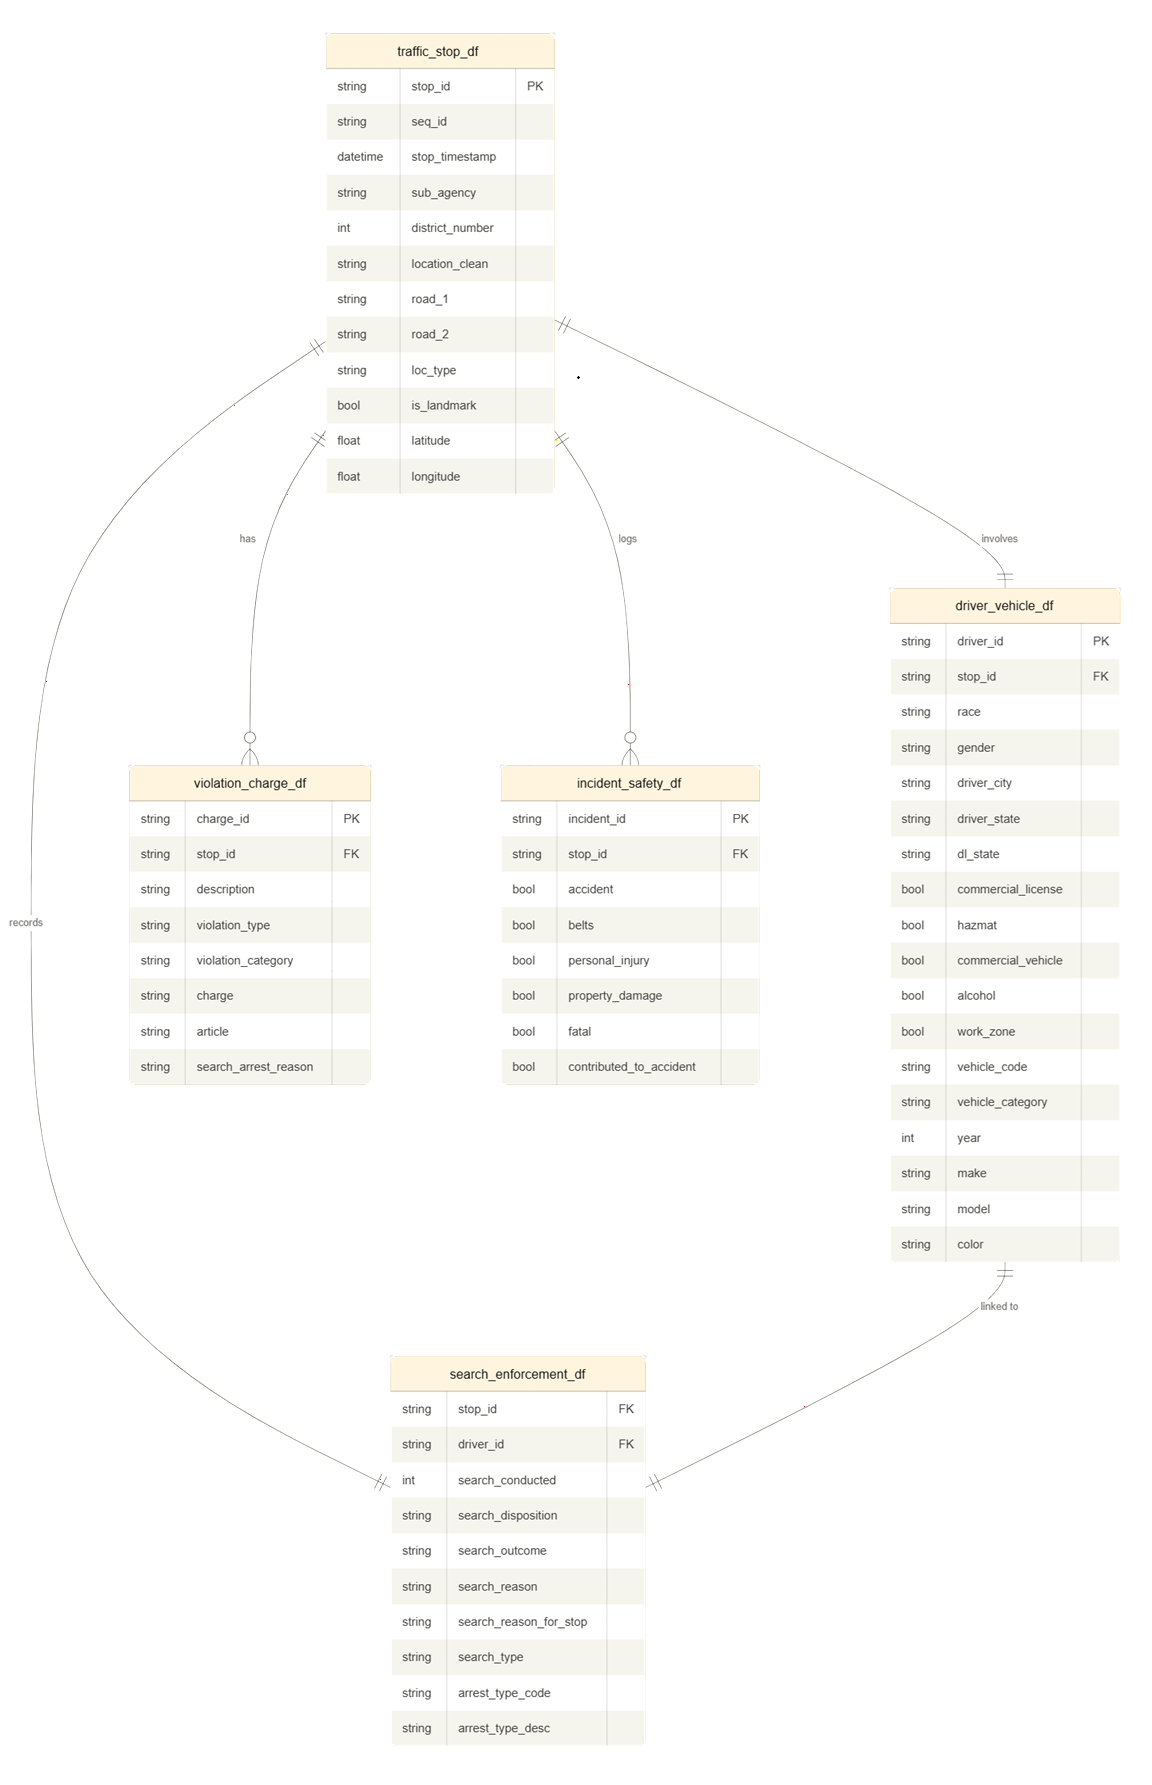

In [3]:
from IPython.display import Image
Image("../images/ER_Diagram.png")

## 4. SQL Table Creation

#### 4.1 Load data CSV 

In [16]:
import pandas as pd
import importlib
import app.db as db
importlib.reload(db)
from app.db import get_engine, run_query, run_write, test_connection


In [17]:
traffic_stop_df = pd.read_csv("../data/traffic_stop_v1.csv")
driver_vehicle_df = pd.read_csv("../data/driver_vehicle_v1.csv")
violation_charge_df = pd.read_csv("../data/violation_charge_v1.csv")
incident_safety_df = pd.read_csv("../data/incident_safety_v1.csv")
search_enforcement_df = pd.read_csv("../data/search_enforcement_v1.csv")

In [18]:
traffic_stop_df.dtypes

stop_id              int64
seq_id              object
stop_timestamp      object
sub_agency          object
district_number    float64
location_clean      object
road_1              object
road_2              object
loc_type            object
is_landmark           bool
latitude           float64
longitude          float64
dtype: object

In [19]:
traffic_stop_df['stop_timestamp']=pd.to_datetime(traffic_stop_df['stop_timestamp'])

In [20]:
traffic_stop_df.dtypes

stop_id                     int64
seq_id                     object
stop_timestamp     datetime64[ns]
sub_agency                 object
district_number           float64
location_clean             object
road_1                     object
road_2                     object
loc_type                   object
is_landmark                  bool
latitude                  float64
longitude                 float64
dtype: object

In [21]:
driver_vehicle_df.dtypes

driver_id               int64
stop_id                 int64
race                   object
gender                 object
driver_city            object
driver_state           object
dl_state               object
commercial_license      int64
hazmat                  int64
commercial_vehicle      int64
alcohol                 int64
work_zone               int64
vehicle_code            int64
vehicle_category       object
year                  float64
make                   object
model                  object
color                  object
dtype: object

In [22]:
driver_vehicle_df['year'] = driver_vehicle_df['year'].astype('Int64')

In [23]:
incident_safety_df.dtypes

incident_id                int64
stop_id                    int64
accident                   int64
belts                      int64
personal_injury            int64
property_damage            int64
fatal                      int64
contributed_to_accident    int64
dtype: object

In [25]:
# Fix search_enforcement_df — deduplicate again
print(f"Before: {search_enforcement_df.shape[0]:,}")

search_enforcement_df = (
    search_enforcement_df
    .sort_values('search_conducted', ascending=False)
    .drop_duplicates(subset=['stop_id'], keep='first')
    .reset_index(drop=True)
)

print(f"After:  {search_enforcement_df.shape[0]:,}")
print(f"Unique stop_ids: {search_enforcement_df['stop_id'].nunique():,}")

# Fix boolean column
search_enforcement_df['search_conducted'] = (
    search_enforcement_df['search_conducted'].astype(int)
)

print(f"\nReady to load: {search_enforcement_df.shape} ✅")


Before: 568,317
After:  568,317
Unique stop_ids: 568,317

Ready to load: (568317, 10) ✅


In [26]:
# Test on startup
if test_connection():
    print("Database connected! ✅")

2026-03-25 09:55:44.258 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Connection successful! ✅
Database connected! ✅


In [27]:
# ============================================================
# STEP 2 — PREPARE DATAFRAMES BEFORE LOADING
# ============================================================

import numpy as np

# Fix datatypes for MySQL compatibility
# traffic_stop — fix district_number
traffic_stop_df['district_number'] = (
    traffic_stop_df['district_number']
    .astype(float)
    .astype('Int64')
)

# driver_vehicle — fix year
driver_vehicle_df['year'] = (
    driver_vehicle_df['year']
    .astype('Int64')
)

# Convert all boolean columns to int (MySQL TINYINT)
bool_cols_incident = ['accident', 'belts', 'personal_injury',
                      'property_damage', 'fatal', 'contributed_to_accident']
for col in bool_cols_incident:
    incident_safety_df[col] = incident_safety_df[col].astype(int)

bool_cols_driver = ['commercial_license', 'hazmat', 'commercial_vehicle',
                    'alcohol', 'work_zone']
for col in bool_cols_driver:
    driver_vehicle_df[col] = driver_vehicle_df[col].astype(int)

search_enforcement_df['search_conducted'] = (
    search_enforcement_df['search_conducted'].astype(int)
)

print("Dataframes prepared! ✅")
print(f"\nShapes:")
print(f"  traffic_stop_df:        {traffic_stop_df.shape}")
print(f"  driver_vehicle_df:      {driver_vehicle_df.shape}")
print(f"  violation_charge_df:    {violation_charge_df.shape}")
print(f"  incident_safety_df:     {incident_safety_df.shape}")
print(f"  search_enforcement_df:  {search_enforcement_df.shape}")

Dataframes prepared! ✅

Shapes:
  traffic_stop_df:        (568317, 12)
  driver_vehicle_df:      (568317, 18)
  violation_charge_df:    (1046801, 8)
  incident_safety_df:     (568317, 8)
  search_enforcement_df:  (568317, 10)


In [ ]:
# ============================================================
# STEP 3 — LOAD DATA IN CORRECT ORDER
# ============================================================

from datetime import datetime

tables = [
    ('traffic_stop',       traffic_stop_df),
    ('driver_vehicle',     driver_vehicle_df),
    ('violation_charge',   violation_charge_df),
    ('incident_safety',    incident_safety_df),
    ('search_enforcement', search_enforcement_df),
]

engine = get_engine()
for table_name, df in tables:
    start = datetime.now()
    try:
        df.to_sql(
            name      = table_name,
            con       = engine,
            if_exists = 'append',
            index     = False,
            method    = 'multi',
            chunksize = 500
        )
        elapsed = (datetime.now() - start).seconds
        print(f"✅ {table_name:25} {df.shape[0]:>10,} rows  ({elapsed}s)")
    except Exception as e:
        print(f"❌ {table_name:25} failed: {e}")

In [ ]:
# ============================================================
# STEP 4 — CREATE INDEXES
# ============================================================

indexes_sql = [
    "CREATE INDEX IF NOT EXISTS idx_stop_timestamp    ON traffic_stop(stop_timestamp)",
    "CREATE INDEX IF NOT EXISTS idx_stop_district     ON traffic_stop(district_number)",
    "CREATE INDEX IF NOT EXISTS idx_driver_stop_id    ON driver_vehicle(stop_id)",
    "CREATE INDEX IF NOT EXISTS idx_driver_race       ON driver_vehicle(race)",
    "CREATE INDEX IF NOT EXISTS idx_driver_make       ON driver_vehicle(make)",
    "CREATE INDEX IF NOT EXISTS idx_violation_stop_id ON violation_charge(stop_id)",
    "CREATE INDEX IF NOT EXISTS idx_violation_cat     ON violation_charge(violation_category)",
    "CREATE INDEX IF NOT EXISTS idx_incident_stop_id  ON incident_safety(stop_id)",
    "CREATE INDEX IF NOT EXISTS idx_search_stop_id    ON search_enforcement(stop_id)",

    # New indexes for speed
    "CREATE INDEX IF NOT EXISTS idx_vc_violation_type ON violation_charge(violation_type)",
    "CREATE INDEX IF NOT EXISTS idx_dv_gender         ON driver_vehicle(gender)",
    "CREATE INDEX IF NOT EXISTS idx_dv_color          ON driver_vehicle(color)",
    "CREATE INDEX IF NOT EXISTS idx_dv_vehicle_cat    ON driver_vehicle(vehicle_category)",
    "CREATE INDEX IF NOT EXISTS idx_se_conducted      ON search_enforcement(search_conducted)",
    "CREATE INDEX IF NOT EXISTS idx_se_outcome        ON search_enforcement(search_outcome)",
    "CREATE INDEX IF NOT EXISTS idx_se_disposition    ON search_enforcement(search_disposition)",
    "CREATE INDEX IF NOT EXISTS idx_ins_accident      ON incident_safety(accident)",
    "CREATE INDEX IF NOT EXISTS idx_ins_fatal         ON incident_safety(fatal)",
    "CREATE INDEX IF NOT EXISTS idx_ts_loc_type       ON traffic_stop(loc_type)",
    "CREATE INDEX IF NOT EXISTS idx_ts_location       ON traffic_stop(location_clean(50))",
]

with engine.connect() as conn:
    for sql in indexes_sql:
        try:
            conn.execute(text(sql))
            print(f"✅ {sql[13:45]}...")
        except Exception as e:
            print(f"⚠️  {e}")
    conn.commit()
print("\nAll indexes created! ✅")

In [29]:
# ============================================================
# STEP 5 — VERIFY LOADING
# ============================================================

print("=" * 55)
print("LOADING VERIFICATION")
print("=" * 55)

tables_to_verify = [
    ('traffic_stop',       'stop_id',     568317),
    ('driver_vehicle',     'driver_id',   568317),
    ('violation_charge',   'charge_id',  1046801),
    ('incident_safety',    'incident_id', 568317),
    ('search_enforcement', 'stop_id',     568317),
]

all_passed = True
for table, pk, expected in tables_to_verify:
    df = run_query(f"SELECT COUNT(*) as cnt FROM {table}")
    actual = df['cnt'].iloc[0]
    status = '✅' if actual == expected else '❌'
    if actual != expected:
        all_passed = False
    print(f"{status} {table:25} {actual:>10,} / {expected:>10,}")

print("=" * 55)
if all_passed:
    print("ALL TABLES VERIFIED SUCCESSFULLY! 🎉")
else:
    print("⚠️  SOME TABLES HAVE ROW COUNT MISMATCH!")
print("=" * 55)

LOADING VERIFICATION
✅ traffic_stop                 568,317 /    568,317
✅ driver_vehicle               568,317 /    568,317
✅ violation_charge           1,046,801 /  1,046,801
✅ incident_safety              568,317 /    568,317
✅ search_enforcement           568,317 /    568,317
ALL TABLES VERIFIED SUCCESSFULLY! 🎉


In [30]:
# ============================================================
# MYSQL VERIFICATION — COMPLETE
# ============================================================

# 1. Check all tables exist
print("=" * 55)
print("1. TABLES IN DATABASE")
print("=" * 55)
print(run_query("SHOW TABLES"))

# 2. Check indexes
print("\n" + "=" * 55)
print("2. INDEXES")
print("=" * 55)
tables = ['traffic_stop', 'driver_vehicle', 'violation_charge',
          'incident_safety', 'search_enforcement']
for table in tables:
    print(f"\n{table}:")
    print(run_query(f"SHOW INDEX FROM {table}")[['Table', 'Key_name', 'Column_name']])

# 3. Check foreign keys
print("\n" + "=" * 55)
print("3. FOREIGN KEYS")
print("=" * 55)
fk_query = """
SELECT 
    TABLE_NAME,
    COLUMN_NAME,
    CONSTRAINT_NAME,
    REFERENCED_TABLE_NAME,
    REFERENCED_COLUMN_NAME
FROM INFORMATION_SCHEMA.KEY_COLUMN_USAGE
WHERE REFERENCED_TABLE_NAME IS NOT NULL
AND TABLE_SCHEMA = 'traffic_violations'
"""
print(run_query(fk_query))

# 4. Check row counts
print("\n" + "=" * 55)
print("4. ROW COUNTS")
print("=" * 55)
for table in tables:
    df = run_query(f"SELECT COUNT(*) as cnt FROM {table}")
    print(f"  {table:25} {df['cnt'].iloc[0]:>10,}")

# 5. Check for NULLs in primary keys
print("\n" + "=" * 55)
print("5. NULL CHECK ON PRIMARY KEYS")
print("=" * 55)
pk_checks = [
    ('traffic_stop',       'stop_id'),
    ('driver_vehicle',     'driver_id'),
    ('violation_charge',   'charge_id'),
    ('incident_safety',    'incident_id'),
    ('search_enforcement', 'stop_id'),
]
for table, pk in pk_checks:
    df = run_query(f"SELECT COUNT(*) as cnt FROM {table} WHERE {pk} IS NULL")
    null_count = df['cnt'].iloc[0]
    status = '✅' if null_count == 0 else '❌'
    print(f"  {status} {table:25} {pk:15} NULLs: {null_count}")

# 6. Check foreign key integrity
print("\n" + "=" * 55)
print("6. FOREIGN KEY INTEGRITY")
print("=" * 55)
fk_integrity = [
    ('driver_vehicle',     'stop_id',   'traffic_stop',   'stop_id'),
    ('violation_charge',   'stop_id',   'traffic_stop',   'stop_id'),
    ('incident_safety',    'stop_id',   'traffic_stop',   'stop_id'),
    ('search_enforcement', 'stop_id',   'traffic_stop',   'stop_id'),
    ('search_enforcement', 'driver_id', 'driver_vehicle', 'driver_id'),
]
for child, child_col, parent, parent_col in fk_integrity:
    df = run_query(f"""
        SELECT COUNT(*) as cnt 
        FROM {child} c
        LEFT JOIN {parent} p ON c.{child_col} = p.{parent_col}
        WHERE p.{parent_col} IS NULL
    """)
    orphans = df['cnt'].iloc[0]
    status = '✅' if orphans == 0 else '❌'
    print(f"  {status} {child:25} → {parent:20} orphans: {orphans}")

# 7. Sample data check
print("\n" + "=" * 55)
print("7. SAMPLE DATA CHECK")
print("=" * 55)
sample = run_query("""
    SELECT 
        ts.stop_id,
        ts.stop_timestamp,
        ts.district_number,
        dv.race,
        dv.make,
        vc.violation_category,
        se.search_conducted,
        ins.accident
    FROM traffic_stop ts
    JOIN driver_vehicle     dv  ON ts.stop_id = dv.stop_id
    JOIN violation_charge   vc  ON ts.stop_id = vc.stop_id
    JOIN search_enforcement se  ON ts.stop_id = se.stop_id
    JOIN incident_safety    ins ON ts.stop_id = ins.stop_id
    LIMIT 5
""")
print(sample.to_string())

# 8. Table sizes on disk
print("\n" + "=" * 55)
print("8. TABLE SIZES ON DISK")
print("=" * 55)
size_query = """
SELECT 
    TABLE_NAME,
    ROUND(DATA_LENGTH/1024/1024, 2)  AS data_mb,
    ROUND(INDEX_LENGTH/1024/1024, 2) AS index_mb,
    ROUND((DATA_LENGTH+INDEX_LENGTH)/1024/1024, 2) AS total_mb
FROM INFORMATION_SCHEMA.TABLES
WHERE TABLE_SCHEMA = 'traffic_violations'
ORDER BY total_mb DESC
"""
print(run_query(size_query))

print("\n" + "=" * 55)
print("MYSQL VERIFICATION COMPLETE! 🎉")
print("=" * 55)

1. TABLES IN DATABASE
  Tables_in_traffic_violations
0               driver_vehicle
1              incident_safety
2           search_enforcement
3                 traffic_stop
4             violation_charge

2. INDEXES

traffic_stop:
          Table            Key_name      Column_name
0  traffic_stop             PRIMARY          stop_id
1  traffic_stop  idx_stop_timestamp   stop_timestamp
2  traffic_stop   idx_stop_district  district_number
3  traffic_stop     idx_ts_loc_type         loc_type
4  traffic_stop     idx_ts_location   location_clean

driver_vehicle:
            Table            Key_name       Column_name
0  driver_vehicle             PRIMARY         driver_id
1  driver_vehicle  idx_driver_stop_id           stop_id
2  driver_vehicle     idx_driver_race              race
3  driver_vehicle     idx_driver_make              make
4  driver_vehicle       idx_dv_gender            gender
5  driver_vehicle        idx_dv_color             color
6  driver_vehicle  idx_dv_vehicle_cat 